In [1]:
import os, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

def seed_all(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

seed_all(42)

PROJECT_ROOT = Path(os.getcwd()).parent
CONFIG_PATH = PROJECT_ROOT / "src" / "config.json"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy {CONFIG_PATH}. Hãy chạy 00_prep_features.ipynb trước.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = json.load(f)

FEATURES = Path(cfg["FEATURES"])
RESULTS  = Path(cfg["RESULTS"])
FIGURES  = Path(cfg["FIGURES"])

# đảm bảo thư mục tồn tại
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FEATURES   :", FEATURES)
print("RESULTS    :", RESULTS)
print("FIGURES    :", FIGURES)


PROJECT_ROOT: D:\STAT3013.Q12_Group01
FEATURES   : D:\STAT3013.Q12_Group01\features
RESULTS    : D:\STAT3013.Q12_Group01\results
FIGURES    : D:\STAT3013.Q12_Group01\figures


In [2]:
orders_path = FEATURES / "repeat30d.parquet"
print("Đang kiểm tra file:", orders_path)

if orders_path.exists():
    orders = pd.read_parquet(orders_path)
    print(f" Đã tải dữ liệu 'orders': {orders.shape}")
else:
    raise FileNotFoundError(
        f" Không tìm thấy file tại: {orders_path}. Hãy chạy NB02 (build_features_repeat30d) trước!"
    )

# 2) Chọn các cột đặc trưng (feature) để dự báo repeat30d
feature_cols = [
    "recency", "frequency", "tenure",
    "basket_value", "basket_qty", "avg_price",
    "discount_rate", "n_items", "n_dept",
    "dow", "weekofyear",
    "promo_display", "promo_mailer", "promo_price_red"
]

# Lọc lại cho chắc: chỉ giữ những cột thực sự có trong orders
feature_cols = [c for c in feature_cols if c in orders.columns]
print("Feature columns dùng trong X:", feature_cols)

if len(feature_cols) == 0:
    raise ValueError("❌ Không còn cột feature nào sau khi lọc! Kiểm tra lại tên cột trong orders.")

# 3) Tạo ma trận X, vector y (label), t (treatment)
X = orders[feature_cols].fillna(0).values
y = orders["repeat30d"].astype(int).values
t = orders["treatment"].astype(int).values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("t shape:", t.shape)

orders[["day", "repeat30d", "treatment"]].head()


Đang kiểm tra file: D:\STAT3013.Q12_Group01\features\repeat30d.parquet
 Đã tải dữ liệu 'orders': (113574, 28)
Feature columns dùng trong X: ['recency', 'frequency', 'tenure', 'basket_value', 'basket_qty', 'avg_price', 'discount_rate', 'n_items', 'n_dept', 'dow', 'weekofyear', 'promo_display', 'promo_mailer', 'promo_price_red']
X shape: (113574, 14)
y shape: (113574,)
t shape: (113574,)


,day,repeat30d,treatment
0,51,1,1
1,67,1,0
2,88,1,0
3,94,1,1
4,101,1,0


In [3]:
orders_path = FEATURES / "repeat30d.parquet"
print("Đang kiểm tra file:", orders_path)

if orders_path.exists():
    orders = pd.read_parquet(orders_path)
    print(f"Đã tải dữ liệu 'orders': {orders.shape}")
else:
    raise FileNotFoundError(
        f"Không tìm thấy file tại: {orders_path}. Hãy chạy NB02 (build_features_repeat30d) trước!"
    )

orders.head()


Đang kiểm tra file: D:\STAT3013.Q12_Group01\features\repeat30d.parquet
Đã tải dữ liệu 'orders': (113574, 28)


,household_key,basket_id,day,week_no,store_id,basket_value,basket_qty,retail_disc,coupon_disc,coupon_match_disc,...,gap_days,repeat30d,prev_day,recency,frequency,monetary_mean_prev,tenure,dow,weekofyear,discount_rate
0,1,27601281299,51,8,436,78.66,34,-16.54,-1.0,0.0,...,16.0,1,NaN,999.0,0,78.660000,0,2,8,0.182328
1,1,27774192959,67,10,436,41.10,14,-8.59,0.0,0.0,...,21.0,1,51.0,16.0,1,78.660000,16,4,10,0.172872
2,1,28024266849,88,13,436,26.90,13,-6.72,0.0,0.0,...,6.0,1,67.0,21.0,2,59.880000,37,4,13,0.199881
3,1,28106322445,94,14,436,63.43,32,-11.08,-0.5,-0.5,...,7.0,1,88.0,6.0,3,48.886667,43,3,14,0.159979
4,1,28235481967,101,15,436,53.45,20,-16.42,0.0,0.0,...,7.0,1,94.0,7.0,4,52.522500,50,3,15,0.235008


In [4]:
dmax = orders["day"].max()

TRAIN_END = int(dmax * 0.70)
VALID_END = int(dmax * 0.85)

mask_train = orders["day"] <= TRAIN_END
mask_val   = (orders["day"] > TRAIN_END) & (orders["day"] <= VALID_END)
mask_test  = orders["day"] > VALID_END

X_train, y_train, t_train = X[mask_train], y[mask_train], t[mask_train]
X_val,   y_val,   t_val   = X[mask_val],   y[mask_val],   t[mask_val]
X_test,  y_test,  t_test  = X[mask_test],  y[mask_test],  t[mask_test]

print("day min/max:", orders["day"].min(), orders["day"].max())
print("TRAIN_END, VALID_END:", TRAIN_END, VALID_END)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Repeat rate test:", y_test.mean(), "| Treated rate test:", t_test.mean())


day min/max: 1 330
TRAIN_END, VALID_END: 230 280
Train: (72697, 14) Val: (20585, 14) Test: (20292, 14)
Repeat rate test: 0.8923220973782772 | Treated rate test: 0.04548590577567514


In [5]:
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xva_s = scaler.transform(X_val) if len(X_val) else None
Xte_s = scaler.transform(X_test)


In [6]:
clf = LogisticRegression(max_iter=200, class_weight="balanced")
clf.fit(Xtr_s, y_train)

proba_te = clf.predict_proba(Xte_s)[:,1]

baseline_metrics = {
    "roc_auc": roc_auc_score(y_test, proba_te),
    "pr_auc": average_precision_score(y_test, proba_te)
}
baseline_metrics


{'roc_auc': 0.7310370883278513, 'pr_auc': 0.9511762967063}

In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [8]:
# tensorize
Xtr_t = torch.tensor(Xtr_s.astype("float32"))
Xva_t = torch.tensor(Xva_s.astype("float32")) if Xva_s is not None else None
Xte_t = torch.tensor(Xte_s.astype("float32"))

ytr_t = torch.tensor(y_train.astype("float32")).unsqueeze(1)
yva_t = torch.tensor(y_val.astype("float32")).unsqueeze(1) if Xva_t is not None else None
yte_t = torch.tensor(y_test.astype("float32")).unsqueeze(1)

train_dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=1024, shuffle=True)
val_dl   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=2048, shuffle=False) if Xva_t is not None else None
test_dl  = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=2048, shuffle=False)



In [9]:
from rtdl_revisiting_models import FTTransformer

ft = FTTransformer(
    n_cont_features=Xtr_s.shape[1],
    cat_cardinalities=None,      
    d_block=64,
    n_blocks=3,
    attention_n_heads=4,
    attention_dropout=0.1,
    ffn_d_hidden_multiplier=4,   
    ffn_dropout=0.1,
    residual_dropout=0.0,
    d_out=1
).to(device)

ft

FTTransformer(
  (cls_embedding): _CLSEmbedding()
  (cont_embeddings): LinearEmbeddings()
  (backbone): FTTransformerBackbone(
    (blocks): ModuleList(
      (0): ModuleDict(
        (attention): MultiheadAttention(
          (W_q): Linear(in_features=64, out_features=64, bias=True)
          (W_k): Linear(in_features=64, out_features=64, bias=True)
          (W_v): Linear(in_features=64, out_features=64, bias=True)
          (W_out): Linear(in_features=64, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (attention_residual_dropout): Dropout(p=0.0, inplace=False)
        (ffn_normalization): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (linear1): Linear(in_features=64, out_features=512, bias=True)
          (activation): _ReGLU()
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
        )
        (ffn_residual_dropout):

In [10]:
opt = torch.optim.AdamW(ft.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()   # output logits

EPOCHS = 10
for ep in range(EPOCHS):
    ft.train()
    losses=[]
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)

        logits = ft(xb, None)   #  x_cat MUST be None
        loss = loss_fn(logits, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    # val
    if val_dl is not None:
        ft.eval()
        with torch.no_grad():
            val_probs=[]
            val_true=[]
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = ft(xb, None)
                val_probs.append(torch.sigmoid(logits).cpu())
                val_true.append(yb.cpu())
            val_probs = torch.cat(val_probs).numpy().ravel()
            val_true  = torch.cat(val_true).numpy().ravel()
            val_roc = roc_auc_score(val_true, val_probs)

        print(f"Epoch {ep+1}/{EPOCHS} | train_loss={np.mean(losses):.4f} | val_roc={val_roc:.4f}")
    else:
        print(f"Epoch {ep+1}/{EPOCHS} | train_loss={np.mean(losses):.4f}")



Epoch 1/10 | train_loss=0.1614 | val_roc=0.7002


Epoch 2/10 | train_loss=0.1409 | val_roc=0.8196


Epoch 3/10 | train_loss=0.1218 | val_roc=0.9023


Epoch 4/10 | train_loss=0.1142 | val_roc=0.9039


Epoch 5/10 | train_loss=0.1126 | val_roc=0.9053


Epoch 6/10 | train_loss=0.1123 | val_roc=0.9060


Epoch 7/10 | train_loss=0.1117 | val_roc=0.9078


Epoch 8/10 | train_loss=0.1115 | val_roc=0.9069


Epoch 9/10 | train_loss=0.1118 | val_roc=0.9081


Epoch 10/10 | train_loss=0.1113 | val_roc=0.9029


In [11]:
ft.eval()
with torch.no_grad():
    probs=[]
    for xb, _ in test_dl:
        xb = xb.to(device)
        logits = ft(xb, None)
        probs.append(torch.sigmoid(logits).cpu())
    probs = torch.cat(probs).numpy().ravel()

ft_metrics = {
    "roc_auc": roc_auc_score(y_test, probs),
    "pr_auc": average_precision_score(y_test, probs)
}
ft_metrics


{'roc_auc': 0.7426732319283323, 'pr_auc': 0.9512025377271079}

In [12]:
class UpliftMLP(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(d,128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,128), nn.ReLU(),
            nn.Linear(128,1), nn.Sigmoid()
        )
    def forward(self,x): return self.net(x)

def train_nn(X,y,epochs=8):
    m=UpliftMLP(X.shape[1]).to(device)
    opt=torch.optim.Adam(m.parameters(), lr=1e-3)
    loss_fn=nn.BCELoss()

    dl=DataLoader(
        TensorDataset(torch.tensor(X.astype("float32")),
                      torch.tensor(y.astype("float32")).unsqueeze(1)),
        batch_size=1024, shuffle=True
    )

    for _ in range(epochs):
        for xb,yb in dl:
            xb,yb = xb.to(device), yb.to(device)
            pred=m(xb)
            loss=loss_fn(pred,yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return m

#  t_train cùng mask với X_train nên không còn lệch shape
m1 = train_nn(Xtr_s[t_train==1], y_train[t_train==1])
m0 = train_nn(Xtr_s[t_train==0], y_train[t_train==0])

with torch.no_grad():
    p1 = m1(torch.tensor(Xte_s.astype("float32")).to(device)).cpu().numpy().ravel()
    p0 = m0(torch.tensor(Xte_s.astype("float32")).to(device)).cpu().numpy().ravel()

uplift = p1 - p0
uplift[:5]



array([0.00291318, 0.03718096, 0.01241076, 0.00774366, 0.01240855],
      dtype=float32)

In [13]:
eval_df = pd.DataFrame({"uplift":uplift, "y":y_test, "t":t_test})
eval_df = eval_df.sort_values("uplift", ascending=False).reset_index(drop=True)
eval_df["decile"] = pd.qcut(eval_df.index, 10, labels=False)

decile_stats = eval_df.groupby("decile").apply(
    lambda g: pd.Series({
        "n": len(g),
        "treated_rate": g[g.t==1].y.mean() if (g.t==1).any() else 0,
        "control_rate": g[g.t==0].y.mean() if (g.t==0).any() else 0,
        "uplift_rate": (g[g.t==1].y.mean() if (g.t==1).any() else 0) -
                       (g[g.t==0].y.mean() if (g.t==0).any() else 0)
    })
).reset_index()

decile_stats



,decile,n,treated_rate,control_rate,uplift_rate
0,0,2030.0,0.589744,0.683914,-0.094170
1,1,2029.0,0.805310,0.824113,-0.018803
2,2,2029.0,0.862385,0.852083,0.010302
3,3,2029.0,0.860927,0.891374,-0.030447
4,4,2029.0,0.898438,0.936875,-0.038438
5,5,2029.0,0.930000,0.920166,0.009834
6,6,2029.0,0.931034,0.929454,0.001580
7,7,2029.0,0.970588,0.944926,0.025662
8,8,2029.0,0.981481,0.961519,0.019962
9,9,2030.0,0.971429,0.985965,-0.014536


In [14]:
eval_df = pd.DataFrame({"uplift": uplift, "y": y_test, "t": t_test})
eval_df = eval_df.sort_values("uplift", ascending=False).reset_index(drop=True)
eval_df["decile"] = pd.qcut(eval_df.index, 10, labels=False)

decile_stats = eval_df.groupby("decile").apply(
    lambda g: pd.Series({
        "n": len(g),
        "treated_rate": g[g.t==1].y.mean() if (g.t==1).any() else 0,
        "control_rate": g[g.t==0].y.mean() if (g.t==0).any() else 0,
        "uplift_rate": (g[g.t==1].y.mean() if (g.t==1).any() else 0) -
                       (g[g.t==0].y.mean() if (g.t==0).any() else 0)
    })
).reset_index()

decile_stats


,decile,n,treated_rate,control_rate,uplift_rate
0,0,2030.0,0.589744,0.683914,-0.094170
1,1,2029.0,0.805310,0.824113,-0.018803
2,2,2029.0,0.862385,0.852083,0.010302
3,3,2029.0,0.860927,0.891374,-0.030447
4,4,2029.0,0.898438,0.936875,-0.038438
5,5,2029.0,0.930000,0.920166,0.009834
6,6,2029.0,0.931034,0.929454,0.001580
7,7,2029.0,0.970588,0.944926,0.025662
8,8,2029.0,0.981481,0.961519,0.019962
9,9,2030.0,0.971429,0.985965,-0.014536



Đang vẽ Calibration Curve...


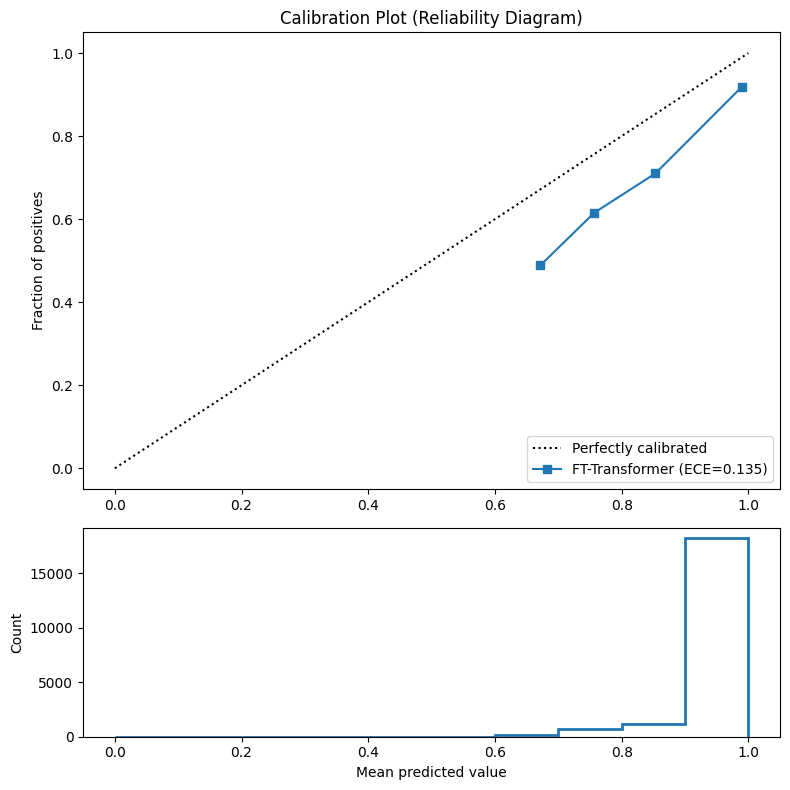

Đã lưu file: D:\STAT3013.Q12_Group01\figures\nb07_calibration_curve.png

Đang vẽ ROI Frontier...


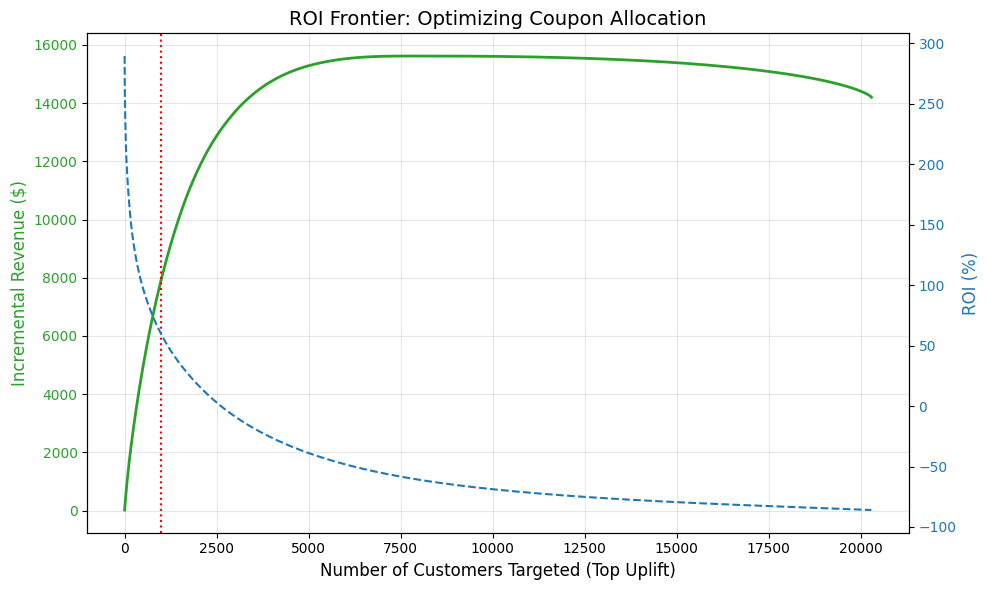

Đã lưu file: D:\STAT3013.Q12_Group01\figures\nb07_roi_frontier.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

OUT_DIR = FIGURES
OUT_DIR.mkdir(exist_ok=True)

# ----------------------------------
print("\nĐang vẽ Calibration Curve...")

plt.figure(figsize=(8, 8))
ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((3, 1), (2, 0))

ax1.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
ece = np.abs(prob_true - prob_pred).mean()

ax1.plot(prob_pred, prob_true, "s-", label=f"FT-Transformer (ECE={ece:.3f})")
ax1.set_ylabel("Fraction of positives")
ax1.set_ylim([-0.05, 1.05])
ax1.legend(loc="lower right")
ax1.set_title("Calibration Plot (Reliability Diagram)")

ax2.hist(probs, range=(0, 1), bins=10, histtype="step", lw=2)
ax2.set_xlabel("Mean predicted value")
ax2.set_ylabel("Count")

plt.tight_layout()
calib_path = OUT_DIR / "nb07_calibration_curve.png"
plt.savefig(calib_path, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu file:", calib_path)

# ----------------------------------
print("\nĐang vẽ ROI Frontier...")

REVENUE_PER_ORDER = 50
COST_PER_COUPON = 5

roi_data = eval_df.sort_values("uplift", ascending=False).reset_index(drop=True)

roi_data["n_targeted"] = roi_data.index + 1
roi_data["total_cost"] = roi_data["n_targeted"] * COST_PER_COUPON
roi_data["cum_uplift"] = roi_data["uplift"].cumsum()
roi_data["incremental_revenue"] = roi_data["cum_uplift"] * REVENUE_PER_ORDER
roi_data["roi"] = (
    (roi_data["incremental_revenue"] - roi_data["total_cost"])
    / roi_data["total_cost"].replace(0, np.nan)
)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = "tab:green"
ax1.set_xlabel("Number of Customers Targeted (Top Uplift)", fontsize=12)
ax1.set_ylabel("Incremental Revenue ($)", color=color, fontsize=12)
ax1.plot(
    roi_data["n_targeted"],
    roi_data["incremental_revenue"],
    color=color,
    linewidth=2,
    label="Revenue Gain",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("ROI (%)", color=color, fontsize=12)
ax2.plot(
    roi_data["n_targeted"],
    roi_data["roi"] * 100,
    color=color,
    linestyle="--",
    label="ROI",
)
ax2.tick_params(axis="y", labelcolor=color)

budget_limit_idx = (roi_data["total_cost"] <= 5000).sum()
if budget_limit_idx > 0:
    ax1.axvline(x=budget_limit_idx, color="red", linestyle=":", label="Budget Limit ($5k)")

plt.title("ROI Frontier: Optimizing Coupon Allocation", fontsize=14)
fig.tight_layout()

roi_path = OUT_DIR / "nb07_roi_frontier.png"
plt.savefig(roi_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu file:", roi_path)


In [16]:

OUT_DIR = RESULTS
OUT_DIR.mkdir(exist_ok=True)

# 1) Logistic Regression metrics
logit_path = OUT_DIR / "nb07_logistic_metrics.csv"
pd.DataFrame([baseline_metrics]).to_csv(logit_path, index=False)
print("Đã lưu nb07_logistic_metrics.csv vào:", logit_path)

# 2) FT-Transformer metrics
ft_path = OUT_DIR / "nb07_fttransformer_metrics.csv"
pd.DataFrame([ft_metrics]).to_csv(ft_path, index=False)
print("Đã lưu nb07_fttransformer_metrics.csv vào:", ft_path)

# 3) Uplift decile table (để vẽ Qini / so sánh uplift theo decile)
deciles_path = OUT_DIR / "nb07_uplift_deciles.csv"
decile_stats.to_csv(deciles_path, index=False)
print("Đã lưu nb07_uplift_deciles.csv vào:", deciles_path)

# 4) Uplift raw scores (numpy)
uplift_path = OUT_DIR / "nb07_uplift.npy"
np.save(uplift_path, uplift)
print("Đã lưu nb07_uplift.npy vào:", uplift_path)

# 5) Evaluation DataFrame cho uplift/ROI frontier
eval_path = OUT_DIR / "nb07_uplift_eval.parquet"
eval_df.to_parquet(eval_path, index=False)
print("Đã lưu nb07_uplift_eval.parquet vào:", eval_path)



Đã lưu nb07_logistic_metrics.csv vào: D:\STAT3013.Q12_Group01\results\nb07_logistic_metrics.csv
Đã lưu nb07_fttransformer_metrics.csv vào: D:\STAT3013.Q12_Group01\results\nb07_fttransformer_metrics.csv
Đã lưu nb07_uplift_deciles.csv vào: D:\STAT3013.Q12_Group01\results\nb07_uplift_deciles.csv
Đã lưu nb07_uplift.npy vào: D:\STAT3013.Q12_Group01\results\nb07_uplift.npy
Đã lưu nb07_uplift_eval.parquet vào: D:\STAT3013.Q12_Group01\results\nb07_uplift_eval.parquet
